# 05b - 20-network latent CVs and rollout comparison

Train two-dimensional latent autoencoders/propagators with 20 training networks per dataset. The notebook focuses on two claims: with more training networks the two latent coordinates carry related but non-identical information, and the latent rollout can be compared against existing GNN rollout baselines.

In [1]:
%matplotlib inline

import os
import sys
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "module://matplotlib_inline.backend_inline")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src" / "lss").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.colors import Normalize

from lss.latent.analysis import framewise_latent_descriptor_sweep
from lss.latent.experiment import run_latent_experiment, seed_everything
from lss.latent.simulation import pearson_r, r2_score
from lss.plotting import PAPER_COLORS, apply_editorial_style, style_axes
from lss.utils import resolve_device

apply_editorial_style()
DEVICE = resolve_device("auto")
DEVICE


/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cuda'

## Settings

Use `FORCE_TRAIN=True` only when you intentionally want to retrain and overwrite the cached 20-network models.

In [2]:
BASE_SEED = 20260710
FORCE_TRAIN = True

TRAIN_COUNT = 20
VAL_COUNT = 20
LATENT_DIM = 2
LATENT_TOKENS = 32
HIDDEN_SIZE = 96
AUTOENCODER_MODEL = "attention"

AE_TRAIN_FRAMES = 100
DYN_TRAIN_FRAMES = 100
AE_MAX_EPOCHS = 80
DYN_MAX_EPOCHS = 80
AE_PATIENCE = 8
DYN_PATIENCE = 8
FRAME_STRIDE = 4
MAX_ANALYSIS_FRAMES_PER_SIM = 100
ROLLOUT_STEPS_GRID = [10, 20, 50, 100, 150, 200]
ROLLOUT_EVAL_MAX_SIMS_PER_SPLIT = 30

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "results" / "05b_20net_latent_rollout"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CASES = {
    "depablo_low_temp": {
        "dataset_name": "depablo_low_temp",
        "label": "dePablo low-T",
        "path": PROJECT_ROOT / "data" / "depablo-near-zero-temp.pt",
    },
    "reid": {
        "dataset_name": "reid",
        "label": "Reid",
        "path": PROJECT_ROOT / "data" / "reid_200_frames.pt",
    },
    "depablo_mixed_temp": {
        "dataset_name": "depablo_mixed_temp",
        "label": "dePablo mixed-T",
        "path": PROJECT_ROOT / "data" / "depablo-10k-mix-temp.pt",
    },
    "lj_noisy": {
        "dataset_name": "lj_noisy",
        "label": "LJ noisy (epsilon=0.01)",
        "path": PROJECT_ROOT / "data" / "lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt",
    },
}

for key, spec in CASES.items():
    assert spec["path"].exists(), f"Missing dataset for {key}: {spec['path']}"

DATASET_STYLE = {
    "depablo_low_temp": {"color": PAPER_COLORS["blue"], "marker": "o", "short": "dePablo low-T"},
    "reid": {"color": PAPER_COLORS["red"], "marker": "s", "short": "Reid"},
    "depablo_mixed_temp": {"color": PAPER_COLORS["green"], "marker": "^", "short": "dePablo mixed-T"},
    "lj_noisy": {"color": PAPER_COLORS["orange"], "marker": "D", "short": "LJ noisy"},
}


In [3]:
def build_case_config(case_key: str, case_spec: dict, *, seed: int) -> tuple[dict, dict]:
    case_dir = OUTPUT_DIR / case_key
    case_dir.mkdir(parents=True, exist_ok=True)
    cache_path = case_dir / (
        f"latent_rollout_{AUTOENCODER_MODEL}_cv{LATENT_DIM}_train{TRAIN_COUNT}_"
        f"frames{AE_TRAIN_FRAMES}_epochs{AE_MAX_EPOCHS}_pat{AE_PATIENCE}_"
        f"dyn_epochs{DYN_MAX_EPOCHS}_dynpat{DYN_PATIENCE}_seed{seed}.pt"
    )
    cfg = {
        "dataset_name": case_spec["dataset_name"],
        "split_seed": seed,
        "split_stratify_temperature": False,
        "min_train_p_ratio": None,
        "device": str(DEVICE),
        "pos_dim": 2,
        "batch_graphs": 4,
        "frame_skip": 1,
        "train_frame_start_order": 0,
        "latent_dim": LATENT_DIM,
        "latent_tokens": LATENT_TOKENS,
        "hidden_size": HIDDEN_SIZE,
        "autoencoder_model": AUTOENCODER_MODEL,
        "edge_feature_dim": 12,
        "ae_target_mode": "normalized_delta",
        "node_feature_mode": "normalized_delta",
        "ae_max_train_frames_per_sim": AE_TRAIN_FRAMES,
        "dyn_max_train_transitions_per_sim": DYN_TRAIN_FRAMES,
        "ae_max_epochs": AE_MAX_EPOCHS,
        "ae_patience": AE_PATIENCE,
        "ae_lr": 5e-5,
        "ae_weight_decay": 1e-5,
        "dyn_max_epochs": DYN_MAX_EPOCHS,
        "dyn_patience": DYN_PATIENCE,
        "dyn_lr": 3e-5,
        "dyn_weight_decay": 1e-4,
        "propagator_use_static_context": True,
        "graph_context_dim": 16,
        "propagator_context_include_temperature": False,
        "propagator_step_stride": 1,
        "initial_velocity": "zero",
        "propagator_objective": "one_step",
        "propagator_model": "delta_mlp",
        "propagator_loss": "delta",
        "propagator_standardize_latent": False,
        "early_stop_min_delta": 1e-5,
        "rollout_steps_grid": ROLLOUT_STEPS_GRID,
        "rollout_eval_max_sims_per_split": ROLLOUT_EVAL_MAX_SIMS_PER_SPLIT,
        "temperature_pratio_window": "full",
        "temperature_pratio_estimator": "robust",
        "temperature_pratio_min_fit_frames": 8,
        "temperature_pratio_min_driven_strain_range": 1e-3,
        "temperature_pratio_smooth_window": 5,
        "should_rollout": True,
        "should_train_propagator": True,
        "force_train": bool(FORCE_TRAIN),
        "cache_path": str(cache_path),
        "model_seed": seed,
        "repeat_idx": 1,
    }
    source_spec = {
        "dataset_name": case_spec["dataset_name"],
        "source_name": case_spec["label"],
        "label": f"{case_spec['label']} CV{LATENT_DIM}, train={TRAIN_COUNT}",
        "path": str(case_spec["path"]),
        "dataset_mixture": [
            {
                "name": case_spec["dataset_name"],
                "label": case_spec["label"],
                "path": str(case_spec["path"]),
                "train_count": TRAIN_COUNT,
                "val_count": VAL_COUNT,
            }
        ],
        "target_mode": cfg["ae_target_mode"],
        "ae_target_mode": cfg["ae_target_mode"],
        "node_feature_mode": cfg["node_feature_mode"],
        "latent_dim": LATENT_DIM,
        "latent_tokens": LATENT_TOKENS,
        "hidden_size": HIDDEN_SIZE,
        "autoencoder_model": AUTOENCODER_MODEL,
        "edge_feature_dim": cfg["edge_feature_dim"],
        "ae_max_train_frames_per_sim": AE_TRAIN_FRAMES,
        "dyn_max_train_transitions_per_sim": DYN_TRAIN_FRAMES,
        "ae_max_epochs": AE_MAX_EPOCHS,
        "ae_patience": AE_PATIENCE,
        "ae_lr": cfg["ae_lr"],
        "ae_weight_decay": cfg["ae_weight_decay"],
        "dyn_max_epochs": DYN_MAX_EPOCHS,
        "dyn_patience": DYN_PATIENCE,
        "dyn_lr": cfg["dyn_lr"],
        "dyn_weight_decay": cfg["dyn_weight_decay"],
        "model_seed": seed,
        "repeat_idx": 1,
    }
    return cfg, source_spec


def run_or_load_case(case_key: str, case_spec: dict) -> dict:
    seed = BASE_SEED + 101 * (list(CASES).index(case_key) + 1)
    seed_everything(seed)
    cfg, source_spec = build_case_config(case_key, case_spec, seed=seed)
    result = run_latent_experiment(source_spec, cfg, device=DEVICE)
    result["case_key"] = case_key
    result["case_label"] = case_spec["label"]
    result["case_cfg"] = cfg
    return result


## Train Or Load 20-Network Models

In [ ]:
results = {key: run_or_load_case(key, spec) for key, spec in CASES.items()}

split_tables = []
for key, result in results.items():
    table = result["split_info"].copy()
    table.insert(0, "case", key)
    split_tables.append(table)
split_info = pd.concat(split_tables, ignore_index=True)
split_info.to_csv(OUTPUT_DIR / "split_info.csv", index=False)
display(split_info)



=== dePablo low-T CV2, train=20 ===
          source                                                                path  total  train  reserved_train_pool  val  test
depablo_low_temp /home/alexz/Documents/course_project/data/depablo-near-zero-temp.pt    200     20                   20   20   160
autoencoder
ae 0001 train=0.60742 val=0.356049 stale=0
ae 0002 train=0.305017 val=0.252704 stale=0
ae 0003 train=0.246324 val=0.229692 stale=0
ae 0004 train=0.227538 val=0.224157 stale=0
ae 0007 train=0.200234 val=0.223621 stale=0
ae 0010 train=0.167002 val=0.273178 stale=3
ae early stop at epoch 0015; best_epoch=0007 best_val=0.223621
latent propagator: objective=one_step step_stride=1 horizons=None train_rows=2000 val_rows=2000
latent propagator: raw z and delta-z (standardization disabled)
propagator 0001 train=0.000116934 val=4.97212e-05 stale=0
propagator 0002 train=2.29412e-05 val=2.59031e-05 stale=0
propagator 0006 train=7.61294e-06 val=1.49449e-05 stale=0
propagator 0010 train=4.89319

## Latent Descriptor Tables

In [ ]:
def trajectory_descriptor_table(frame_df: pd.DataFrame, *, case_key: str, case_label: str) -> pd.DataFrame:
    z_cols = sorted(
        [col for col in frame_df.columns if col.startswith("z") and col[1:].isdigit()],
        key=lambda col: int(col[1:]),
    )
    rows = []
    for (split, sim_idx), group in frame_df.sort_values(["split", "sim_idx", "frame_idx"]).groupby(["split", "sim_idx"]):
        first = group.iloc[0]
        last = group.iloc[-1]
        time = group["frame_idx"].to_numpy(float)
        row = {
            "case": case_key,
            "case_label": case_label,
            "split": split,
            "sim_idx": int(sim_idx),
            "source": first.get("source", case_label),
            "temperature": float(first.get("temperature", np.nan)),
            "n_encoded_frames": int(len(group)),
            "first_frame": int(first["frame_idx"]),
            "last_frame": int(last["frame_idx"]),
            "final_p_ratio": float(first["side_final_trajectory_p_ratio"]),
        }
        for z_col in z_cols:
            values = group[z_col].to_numpy(float)
            slope, intercept = np.polyfit(time, values, deg=1)
            residual = values - (slope * time + intercept)
            row[f"{z_col}_initial"] = float(values[0])
            row[f"{z_col}_final"] = float(values[-1])
            row[f"{z_col}_slope"] = float(slope)
            row[f"{z_col}_std"] = float(np.nanstd(values))
            row[f"{z_col}_detrended_std"] = float(np.nanstd(residual))
        rows.append(row)
    return pd.DataFrame(rows)


frame_tables = []
descriptor_tables = []
score_tables = []
rollout_tables = []

for key, result in results.items():
    frame_df, score_df, prediction_df, weight_df = framewise_latent_descriptor_sweep(
        result,
        device=DEVICE,
        frame_stride=FRAME_STRIDE,
        max_frames_per_sim=MAX_ANALYSIS_FRAMES_PER_SIM,
    )
    frame_df.insert(0, "case", key)
    frame_df.insert(1, "case_label", result["case_label"])
    score_df.insert(0, "case", key)
    score_df.insert(1, "case_label", result["case_label"])
    descriptor_df_case = trajectory_descriptor_table(frame_df, case_key=key, case_label=result["case_label"])

    case_dir = OUTPUT_DIR / key
    frame_df.to_csv(case_dir / "framewise_latent_table.csv", index=False)
    descriptor_df_case.to_csv(case_dir / "trajectory_latent_descriptors.csv", index=False)
    score_df.to_csv(case_dir / "framewise_readout_scores.csv", index=False)
    rollout_stats = result["rollout_stats"].copy()
    rollout_stats.insert(0, "case", key)
    rollout_stats.insert(1, "case_label", result["case_label"])
    rollout_stats.to_csv(case_dir / "rollout_stats.csv", index=False)
    rollout_tables.append(rollout_stats)

    frame_tables.append(frame_df)
    descriptor_tables.append(descriptor_df_case)
    score_tables.append(score_df)

frame_df = pd.concat(frame_tables, ignore_index=True)
descriptor_df = pd.concat(descriptor_tables, ignore_index=True)
score_df = pd.concat(score_tables, ignore_index=True)
rollout_stats_df = pd.concat(rollout_tables, ignore_index=True)

frame_df.to_csv(OUTPUT_DIR / "all_framewise_latent_table.csv", index=False)
descriptor_df.to_csv(OUTPUT_DIR / "all_trajectory_latent_descriptors.csv", index=False)
score_df.to_csv(OUTPUT_DIR / "all_framewise_readout_scores.csv", index=False)
rollout_stats_df.to_csv(OUTPUT_DIR / "all_latent_rollout_stats.csv", index=False)

display(descriptor_df.head())


,case,case_label,split,sim_idx,source,temperature,n_encoded_frames,first_frame,last_frame,final_p_ratio,z0_initial,z0_final,z0_slope,z0_std,z0_detrended_std,z1_initial,z1_final,z1_slope,z1_std,z1_detrended_std
0,depablo_low_temp,dePablo low-T,test,0,depablo_low_temp,1.000000e-07,51,0,199,0.364319,-1.596400,4.038169,0.028341,1.675473,0.161003,-3.034663,7.878631,0.054897,3.246986,0.327454
1,depablo_low_temp,dePablo low-T,test,1,depablo_low_temp,1.000000e-07,51,0,199,-0.421309,1.646077,8.913921,0.036727,2.163096,0.089919,3.517760,18.154257,0.073977,4.357276,0.188514
2,depablo_low_temp,dePablo low-T,test,2,depablo_low_temp,1.000000e-07,51,0,199,-0.247980,0.281083,7.160922,0.034547,2.035036,0.091988,0.829093,14.536062,0.068841,4.055308,0.188053
3,depablo_low_temp,dePablo low-T,test,3,depablo_low_temp,1.000000e-07,51,0,199,-0.258473,1.320432,8.232075,0.034678,2.045070,0.134546,2.800843,16.624580,0.069367,4.091310,0.276994
4,depablo_low_temp,dePablo low-T,test,4,depablo_low_temp,1.000000e-07,51,0,199,0.336450,-1.553714,3.748699,0.026635,1.571547,0.114859,-2.937298,7.278988,0.051318,3.028947,0.235148


## P-Ratio Readouts From Latent Descriptors

In [ ]:
def fit_predict_linear(train_df: pd.DataFrame, test_df: pd.DataFrame, feature_cols: list[str], target_col: str, ridge: float = 1e-6) -> dict:
    train = train_df[feature_cols + [target_col]].replace([np.inf, -np.inf], np.nan).dropna()
    test = test_df[feature_cols + [target_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(feature_cols) == 0:
        raise ValueError("No feature columns were supplied for the readout.")
    if len(train) < 3 or len(test) < 3:
        raise ValueError(f"Need at least 3 train and 3 test rows for {feature_cols}; got train={len(train)}, test={len(test)}.")
    X_train = train[feature_cols].to_numpy(float)
    y_train = train[target_col].to_numpy(float)
    x_mean = X_train.mean(axis=0, keepdims=True)
    x_std = X_train.std(axis=0, keepdims=True) + 1e-12
    Xz_train = (X_train - x_mean) / x_std
    design = np.column_stack([np.ones(len(train)), Xz_train])
    penalty = np.eye(design.shape[1])
    penalty[0, 0] = 0.0
    coef = np.linalg.solve(design.T @ design + float(ridge) * penalty, design.T @ y_train)
    Xz_test = (test[feature_cols].to_numpy(float) - x_mean) / x_std
    pred = np.column_stack([np.ones(len(test)), Xz_test]) @ coef
    return {
        "r2": r2_score(test[target_col], pred),
        "pearson_r": pearson_r(test[target_col], pred),
        "n_val": int(len(train)),
        "n_test": int(len(test)),
        "n_features": int(len(feature_cols)),
    }

readout_rows = []
for case_key, group in descriptor_df.groupby("case"):
    z_initial = sorted([col for col in group.columns if col.startswith("z") and col.endswith("_initial")], key=lambda col: int(col[1:].split("_")[0]))
    z_slope = sorted([col for col in group.columns if col.startswith("z") and col.endswith("_slope")], key=lambda col: int(col[1:].split("_")[0]))
    feature_sets = {
        "Initial latent": z_initial,
        "Latent slope": z_slope,
        "Initial + slope": z_initial + z_slope,
    }
    val = group[group["split"].eq("val")]
    test = group[group["split"].eq("test")]
    for label, cols in feature_sets.items():
        metrics = fit_predict_linear(val, test, cols, "final_p_ratio")
        readout_rows.append({"case": case_key, "case_label": group["case_label"].iloc[0], "feature_set": label, **metrics})
    for col in z_initial + z_slope:
        metrics = fit_predict_linear(val, test, [col], "final_p_ratio")
        readout_rows.append({"case": case_key, "case_label": group["case_label"].iloc[0], "feature_set": col, **metrics})

readout_summary = pd.DataFrame(readout_rows).sort_values(["case", "r2"], ascending=[True, False])
readout_summary.to_csv(OUTPUT_DIR / "p_ratio_readout_summary.csv", index=False)
display(readout_summary[["case_label", "feature_set", "r2", "pearson_r", "n_val", "n_test", "n_features"]].round(3))


,case_label,feature_set,r2,pearson_r,n_val,n_test,n_features
2,dePablo low-T,Initial + slope,0.961,0.982,20,160,4
0,dePablo low-T,Initial latent,0.959,0.981,20,160,2
4,dePablo low-T,z1_initial,0.941,0.971,20,160,1
3,dePablo low-T,z0_initial,0.938,0.969,20,160,1
1,dePablo low-T,Latent slope,0.911,0.956,20,160,2
6,dePablo low-T,z1_slope,0.821,0.909,20,160,1
5,dePablo low-T,z0_slope,0.804,0.900,20,160,1
8,dePablo mixed-T,Latent slope,0.960,0.982,20,260,2
9,dePablo mixed-T,Initial + slope,0.955,0.982,20,260,4
13,dePablo mixed-T,z1_slope,0.884,0.952,20,260,1


Plot: normalized initial latent coordinate versus Poisson Ratio, trained with 20 networks


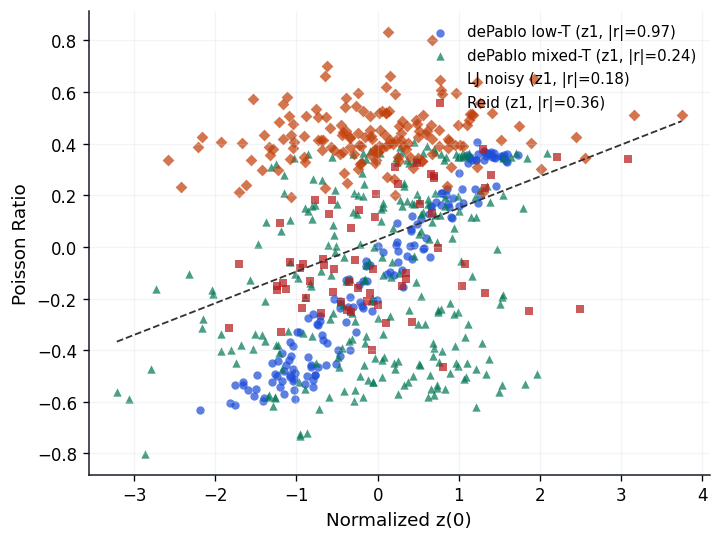

In [ ]:
print("Plot: normalized initial latent coordinate versus Poisson Ratio, trained with 20 networks")
fig, ax = plt.subplots(figsize=(5.9, 4.4), constrained_layout=True)
combined = []
for case_key, group in descriptor_df[descriptor_df["split"].eq("test")].groupby("case"):
    initial_cols = sorted([col for col in group.columns if col.startswith("z") and col.endswith("_initial")], key=lambda col: int(col[1:].split("_")[0]))
    valid = group[["final_p_ratio", *initial_cols]].replace([np.inf, -np.inf], np.nan).dropna()
    correlations = {col: pearson_r(valid[col], valid["final_p_ratio"]) for col in initial_cols}
    z_col = max(correlations, key=lambda col: abs(correlations[col]))
    r = correlations[z_col]
    z = valid[z_col].to_numpy(float)
    scale = np.nanstd(z)
    z_norm = (z - np.nanmean(z)) / scale
    if np.isfinite(r) and r < 0:
        z_norm = -z_norm
    y = valid["final_p_ratio"].to_numpy(float)
    style = DATASET_STYLE.get(case_key, {"color": None, "marker": "o", "short": group["case_label"].iloc[0]}) if "DATASET_STYLE" in globals() else {"color": None, "marker": "o", "short": group["case_label"].iloc[0]}
    ax.scatter(z_norm, y, s=25, alpha=0.72, linewidth=0, color=style.get("color"), marker=style.get("marker", "o"), label=f"{style['short']} ({z_col.replace('_initial', '')}, |r|={abs(r):.2f})")
    combined.append(pd.DataFrame({"z": z_norm, "p_ratio": y}))
all_points = pd.concat(combined, ignore_index=True)
slope, intercept = np.polyfit(all_points["z"], all_points["p_ratio"], deg=1)
xx = np.linspace(float(all_points["z"].min()), float(all_points["z"].max()), 120)
ax.plot(xx, slope * xx + intercept, color="0.20", lw=1.1, ls="--")
style_axes(ax, xlabel="Normalized z(0)", ylabel="Poisson Ratio", legend=True)
plt.show()
fig.savefig(OUTPUT_DIR / "normalized_initial_latent_vs_pratio.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "normalized_initial_latent_vs_pratio.pdf", bbox_inches="tight")


## What The Two Latent Coordinates Encode

,case,case_label,coordinate,Poisson Ratio,trajectory progress,x strain,y strain,RMS displacement,nonaffinity,temperature
0,depablo_low_temp,dePablo low-T,z0,-0.670,0.709,-0.706,-0.752,0.753,0.939,NaN
1,depablo_low_temp,dePablo low-T,z1,-0.685,0.693,-0.690,-0.767,0.742,0.940,NaN
2,depablo_mixed_temp,dePablo mixed-T,z0,-0.428,-0.813,0.813,-0.368,-0.608,-0.084,-0.024
3,depablo_mixed_temp,dePablo mixed-T,z1,-0.542,0.721,-0.723,-0.755,0.738,0.406,-0.005
4,lj_noisy,LJ noisy (epsilon=0.01),z0,0.117,0.909,-0.908,0.893,0.889,0.868,NaN
5,lj_noisy,LJ noisy (epsilon=0.01),z1,0.116,0.910,-0.909,0.893,0.891,0.870,NaN
6,reid,Reid,z0,0.414,-0.610,0.611,0.591,-0.635,-0.838,NaN
7,reid,Reid,z1,-0.413,0.610,-0.611,-0.590,0.635,0.837,NaN


Plot: framewise correlations show that z0 and z1 encode related but non-identical quantities


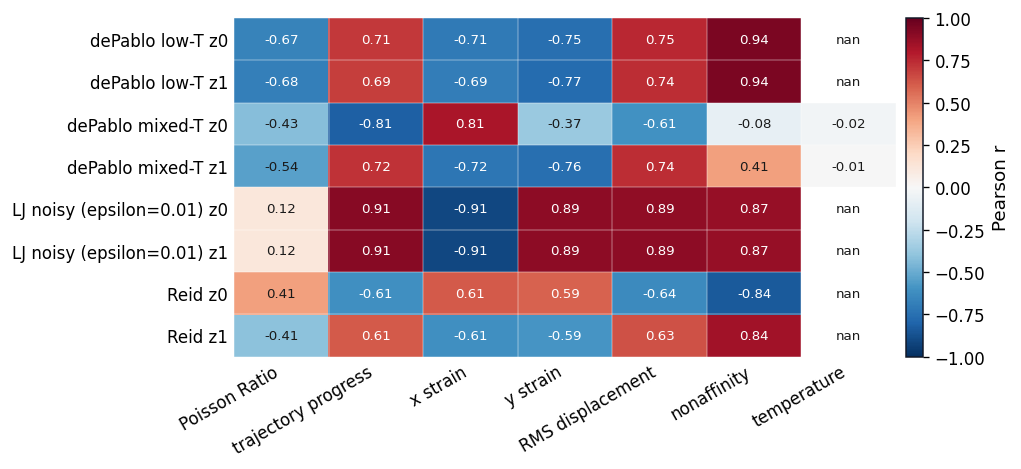

In [ ]:
correlation_metrics = {
    "Poisson Ratio": "side_final_trajectory_p_ratio",
    "trajectory progress": "frame_progress",
    "x strain": "side_strain_x",
    "y strain": "side_strain_y",
    "RMS displacement": "rms_disp",
    "nonaffinity": "nonaffine_rms",
    "temperature": "temperature",
}

rows = []
for case_key, group in frame_df.groupby("case"):
    z_cols = sorted([col for col in group.columns if col.startswith("z") and col[1:].isdigit()], key=lambda col: int(col[1:]))
    for z_col in z_cols:
        row = {"case": case_key, "case_label": group["case_label"].iloc[0], "coordinate": z_col}
        for label, metric_col in correlation_metrics.items():
            row[label] = pearson_r(group[z_col], group[metric_col])
        rows.append(row)
coordinate_correlation = pd.DataFrame(rows)
coordinate_correlation.to_csv(OUTPUT_DIR / "framewise_coordinate_correlations.csv", index=False)
display(coordinate_correlation.round(3))

print("Plot: framewise correlations show that z0 and z1 encode related but non-identical quantities")
plot_df = coordinate_correlation.copy()
plot_df["row"] = plot_df["case_label"] + " " + plot_df["coordinate"]
heat = plot_df.set_index("row")[list(correlation_metrics)]
values = heat.to_numpy(float)
fig, ax = plt.subplots(figsize=(8.4, 3.8), constrained_layout=True)
image = ax.imshow(values, cmap="RdBu_r", vmin=-1.0, vmax=1.0, aspect="auto")
ax.set_xticks(np.arange(heat.shape[1]))
ax.set_xticklabels(heat.columns, rotation=30, ha="right")
ax.set_yticks(np.arange(heat.shape[0]))
ax.set_yticklabels(heat.index)
ax.tick_params(axis="both", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, heat.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, heat.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.1)
ax.tick_params(which="minor", bottom=False, left=False)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = values[i, j]
        label = f"{val:.2f}"
        ax.text(j, i, label, ha="center", va="center", color="white" if abs(val) > 0.55 else "0.10", fontsize=8.0)
cb = fig.colorbar(image, ax=ax, pad=0.015, fraction=0.045)
cb.set_label("Pearson r")
plt.show()
fig.savefig(OUTPUT_DIR / "framewise_coordinate_correlation_heatmap.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "framewise_coordinate_correlation_heatmap.pdf", bbox_inches="tight")


## Latent Rollout

In [ ]:
display_cols = ["case_label", "split", "rollout_steps", "rollout_position_r2", "p_ratio_r2", "p_ratio_pearson", "final_pos_mse"]
display(rollout_stats_df[display_cols].round(4))

print("Plot: latent rollout quality versus rollout horizon")
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8), constrained_layout=True)
test_stats = rollout_stats_df[rollout_stats_df["split"].eq("test")].copy()
for case_key, group in test_stats.groupby("case"):
    style = DATASET_STYLE.get(case_key, {"color": None, "marker": "o", "short": case_key})
    group = group.sort_values("rollout_steps")
    axes[0].plot(group["rollout_steps"], group["rollout_position_r2"], marker=style["marker"], color=style["color"], lw=1.8, label=style["short"])
    axes[1].plot(group["rollout_steps"], group["p_ratio_r2"], marker=style["marker"], color=style["color"], lw=1.8, label=style["short"])
style_axes(axes[0], xlabel="rollout horizon", ylabel="position R2", legend=True)
style_axes(axes[1], xlabel="rollout horizon", ylabel="Poisson Ratio R2", legend=True)
plt.show()
fig.savefig(OUTPUT_DIR / "latent_rollout_quality.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "latent_rollout_quality.pdf", bbox_inches="tight")


KeyError: "['split', 'rollout_steps', 'rollout_position_r2', 'p_ratio_r2', 'p_ratio_pearson', 'final_pos_mse'] not in index"

## Existing GNN Rollout Comparisons

This section loads existing 04e comparison CSVs when available. These are useful for the rollout narrative, but check the paths and labels before treating them as exactly matched splits.

,comparison,model,source,step,n,p_ratio_r2,p_ratio_pearson,position_mse
0,"dePablo mixed-T, train=20",latent simulator,depablo,10,150,0.0000,0.1373,0.0013
1,"dePablo mixed-T, train=20",latent simulator,depablo,20,150,0.0000,0.3699,0.0013
2,"dePablo mixed-T, train=20",latent simulator,depablo,50,150,0.6088,0.8419,0.0015
3,"dePablo mixed-T, train=20",latent simulator,depablo,100,150,0.8144,0.9254,0.0016
4,"dePablo mixed-T, train=20",latent simulator,depablo,150,150,0.8840,0.9486,0.0019
5,"dePablo mixed-T, train=20",latent simulator,all,10,150,0.0000,0.1373,0.0013
6,"dePablo mixed-T, train=20",latent simulator,all,20,150,0.0000,0.3699,0.0013
7,"dePablo mixed-T, train=20",latent simulator,all,50,150,0.6088,0.8419,0.0015
8,"dePablo mixed-T, train=20",latent simulator,all,100,150,0.8144,0.9254,0.0016
9,"dePablo mixed-T, train=20",latent simulator,all,150,150,0.8840,0.9486,0.0019


Plot: existing latent simulator versus GNN rollout comparisons


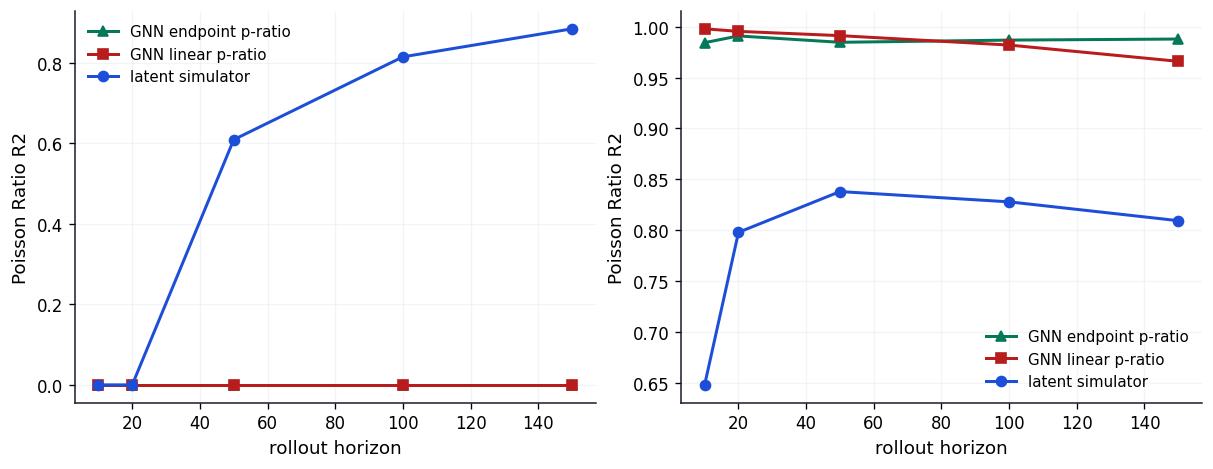

In [ ]:
GNN_COMPARISON_PATHS = {
    "dePablo mixed-T, train=20": PROJECT_ROOT / "notebooks" / "results" / "04e_train_mixed_latent_vs_gnn" / "depablo_mixed_temp_depablo_mixed_temp_tr20_val20_trajectory_linear" / "step_metrics_comparison.csv",
    "Reid with angles, train=20": PROJECT_ROOT / "notebooks" / "results" / "04e_train_mixed_latent_vs_gnn" / "reid_with_angles_reid_with_angles_tr20_val20_endpoint" / "step_metrics_comparison.csv",
}

comparison_parts = []
for label, path in GNN_COMPARISON_PATHS.items():
    df = pd.read_csv(path)
    df.insert(0, "comparison", label)
    comparison_parts.append(df)

if comparison_parts:
    gnn_comparison = pd.concat(comparison_parts, ignore_index=True)
    gnn_comparison.to_csv(OUTPUT_DIR / "existing_gnn_rollout_comparison.csv", index=False)
    display(gnn_comparison[["comparison", "model", "source", "step", "n", "p_ratio_r2", "p_ratio_pearson", "position_mse"]].round(4))

    print("Plot: existing latent simulator versus GNN rollout comparisons")
    comparisons = list(gnn_comparison["comparison"].drop_duplicates())
    fig, axes = plt.subplots(1, len(comparisons), figsize=(5.0 * len(comparisons), 3.8), squeeze=False, constrained_layout=True)
    model_styles = {
        "latent simulator": {"color": PAPER_COLORS["blue"], "marker": "o"},
        "GNN linear p-ratio": {"color": PAPER_COLORS["red"], "marker": "s"},
        "GNN endpoint p-ratio": {"color": PAPER_COLORS["green"], "marker": "^"},
    }
    for ax, comparison in zip(axes[0], comparisons):
        subset = gnn_comparison[gnn_comparison["comparison"].eq(comparison)]
        subset = subset[subset["source"].ne("all")]
        for model, group in subset.groupby("model"):
            style = model_styles.get(model, {"color": None, "marker": "o"})
            group = group.sort_values("step")
            ax.plot(group["step"], group["p_ratio_r2"], marker=style["marker"], color=style["color"], lw=1.8, label=model)
        style_axes(ax, xlabel="rollout horizon", ylabel="Poisson Ratio R2", legend=True)
    plt.show()
    fig.savefig(OUTPUT_DIR / "existing_gnn_rollout_comparison.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / "existing_gnn_rollout_comparison.pdf", bbox_inches="tight")
else:
    print("No existing GNN comparison CSVs found.")


## Notes For The Paper Narrative

- With 20 training networks, inspect whether `z0` and `z1` have different correlation signatures rather than treating the 2D latent as two interchangeable axes.
- The readout table asks whether initial latent position, latent trajectory slope, or both carry Poisson-ratio information.
- The rollout section separates representation quality from dynamical prediction quality.
- The GNN comparison section currently reuses existing 04e outputs; verify split matching before using the comparison as a final quantitative claim.